## MWU Blackjack
A small blackjack environment and an MWU agent\
The environment deals from a fresh deck every game\
1v1 Player vs Dealer games\
The dealer plays a traditional house strategy: hit below 17

In [ ]:
import random
import math
from collections import defaultdict
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


class BlackJack:
    deck_template = {
        11: 4,
        10: 16,
        9: 4,
        8: 4,
        7: 4,
        6: 4,
        5: 4,
        4: 4,
        3: 4,
        2: 4
    }

    def __init__(self):
        self.deck = BlackJack.deck_template.copy()
        self.player_hand = []
        self.dealer_hand = []
        self.deal()

    def draw(self):
        """Draw a card from the deck."""
        cards, weights = list(self.deck.keys()), list(self.deck.values())
        card = random.choices(cards, weights=weights)[0]
        self.deck[card] -= 1
        if self.deck[card] == 0:
            del self.deck[card]
        return card

    def hand_value(self, hand):
        """Return (hard_sum, soft_sum) for a hand."""
        hard = sum(1 if c == 11 else c for c in hand)
        soft = hard
        aces = hand.count(11)
        while aces > 0 and soft + 10 <= 21:
            soft += 10
            aces -= 1
        return hard, soft

    def deal(self):
        """Initial deal for player and dealer."""
        self.player_hand = [self.draw()]
        self.dealer_hand = [self.draw()]
        self.player_hand.append(self.draw())
        self.dealer_hand.append(self.draw())

    def player_values(self):
        return self.hand_value(self.player_hand)

    def dealer_values(self):
        return self.hand_value(self.dealer_hand)

    @property
    def dealer_shown(self):
        return self.dealer_hand[1]

    def dealer_play(self):
        """Dealer hits until reaching hard/soft ≥ 17."""
        while True:
            hard, soft = self.dealer_values()
            best = soft if soft <= 21 else hard
            if best >= 17:
                return best
            self.dealer_hand.append(self.draw())

    def result(self):
        """Compute reward for player."""
        player_hard, player_soft = self.player_values()
        player_best = player_soft if player_soft <= 21 else player_hard
        if player_best > 21:
            return -1  # player busts

        dealer_best = self.dealer_play()
        if dealer_best > 21:
            return 1
        if player_best > dealer_best:
            return 1
        elif player_best == dealer_best:
            return 0
        else:
            return -1


Win rate: 41.52% after 1000000 hands


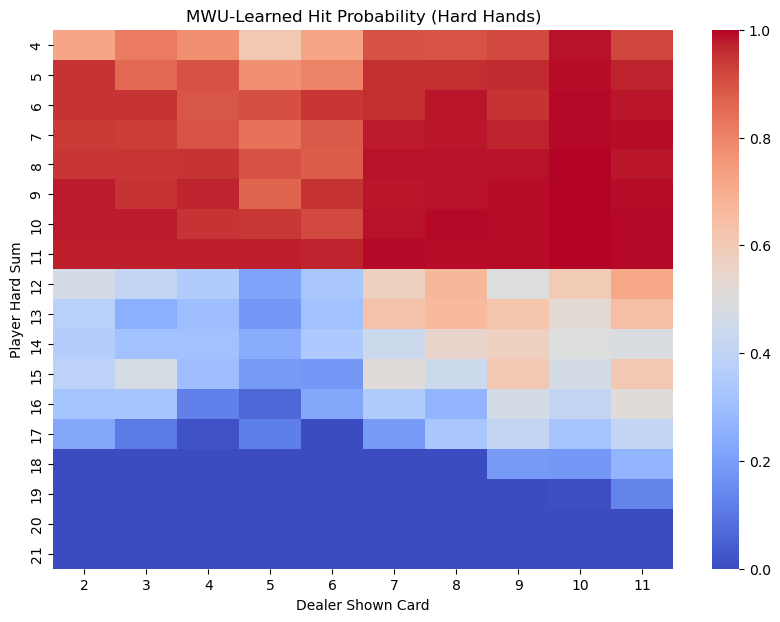

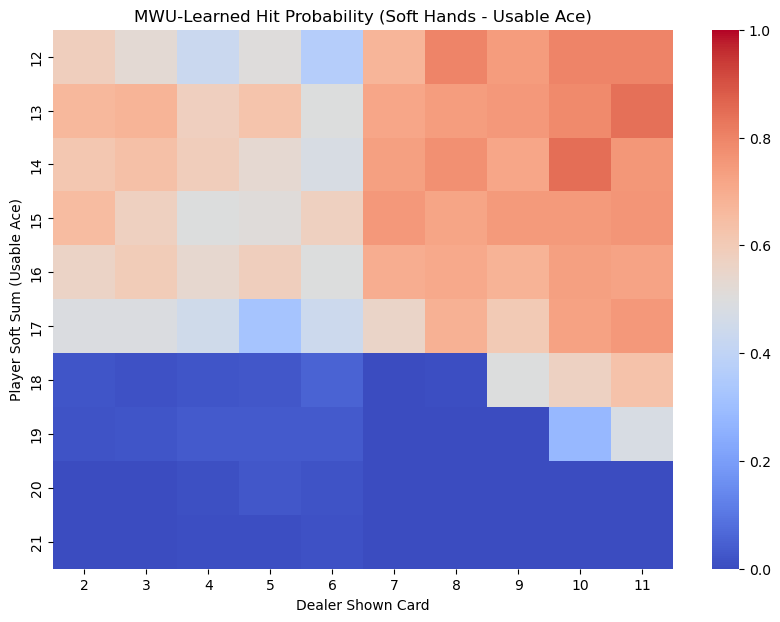

In [19]:

class MWUAgent:
    def __init__(self, eta=0.05):
        self.eta = eta
        self.weights = defaultdict(lambda: [0.5, 0.5])  # [hit, stand]

    def policy(self, state):
        return self.weights[state]

    def act(self, state):
        probs = self.policy(state)
        return random.choices(["hit", "stand"], weights=probs)[0]

    def update(self, state, action, reward):
        p_hit, p_stand = self.weights[state]

        # MWU update on probabilities directly
        if action == "hit":
            p_hit *= math.exp(self.eta * reward)
        else:
            p_stand *= math.exp(self.eta * reward)

        # Renormalize to stay in [0,1] simplex
        total = p_hit + p_stand
        if total == 0:
            p_hit, p_stand = 0.5, 0.5
        else:
            p_hit /= total
            p_stand /= total

        self.weights[state] = [p_hit, p_stand]


def simulate(episodes=100000):
    agent = MWUAgent(eta=0.05)
    results = []

    for _ in range(episodes):
        env = BlackJack()
        hard, soft = env.player_values()
        dealer_card = env.dealer_shown
        has_ace = 11 in env.player_hand
        state = (dealer_card, hard, soft) if has_ace else (dealer_card, soft)
        done = False

        while not done:
            action = agent.act(state)

            if action == "hit":
                env.player_hand.append(env.draw())
                hard, soft = env.player_values()
                has_ace = 11 in env.player_hand
                if min(hard, soft) > 21:
                    reward = -1
                    done = True
                else:
                    state = (dealer_card, hard, soft) if has_ace else (dealer_card, soft)
                    continue
            else:
                reward = env.result()
                done = True

            agent.update(state, action, reward)
            results.append(reward)

    win_rate = (sum(1 for r in results if r == 1) / len(results)) * 100
    print(f"Win rate: {win_rate:.2f}% after {episodes} hands")

    # === Visualization ===
    # Separate hard and soft state maps
    data_hard, data_soft = [], []

    for state, (w_hit, w_stand) in agent.weights.items():
        hit_prob = w_hit / (w_hit + w_stand)

        if len(state) == 2:
            dealer, total = state
            data_hard.append({
                "Dealer": dealer,
                "PlayerSum": total,
                "HitProb": hit_prob
            })
        elif len(state) == 3:
            dealer, hard, soft = state
            data_soft.append({
                "Dealer": dealer,
                "PlayerSum": soft,
                "HitProb": hit_prob
            })

    # Helper to plot a dataframe if nonempty
    def plot_state_heatmap(df, title, ylabel):
        if not df:
            return
        df = pd.DataFrame(df)
        df_mean = df.groupby(["PlayerSum", "Dealer"], as_index=False)["HitProb"].mean()
        pivot = df_mean.pivot(index="PlayerSum", columns="Dealer", values="HitProb")

        plt.figure(figsize=(10, 7))
        sns.heatmap(pivot, cmap="coolwarm", vmin=0, vmax=1)
        plt.title(title)
        plt.xlabel("Dealer Shown Card")
        plt.ylabel(ylabel)
        plt.show()

    # --- Three plots ---
    plot_state_heatmap(data_hard,
                    "MWU-Learned Hit Probability (Hard Hands)",
                    "Player Hard Sum")
    plot_state_heatmap(data_soft,
                    "MWU-Learned Hit Probability (Soft Hands - Usable Ace)",
                    "Player Soft Sum (Usable Ace)")

    return agent



trained_agent = simulate(1_000_000)


We can see that under MWU our agent notices the dealer's threshold to hit and adjusts weights to allow the dealer to bust. Where human players would likely hit on 12 and dealer showing 6 to beat a possible hidden 16 or 17, our MWU agent finds more success standing on 16~17 and letting the dealer possibly bust when it's known they will hit until 17. We also see the agent preferring to stand when the dealer is showing a 5. Standing with 12 is very intentionally trying to get the dealer to bust.\
When our agent has an ace in-hand, it tends to hit up to 17 with safety of falling back on the hard sum (treating the ace as 1). We see that the agent gets biased to hit on higher hands the higher the dealer's shown card is.

Win rate: 41.98% after 10000000 hands


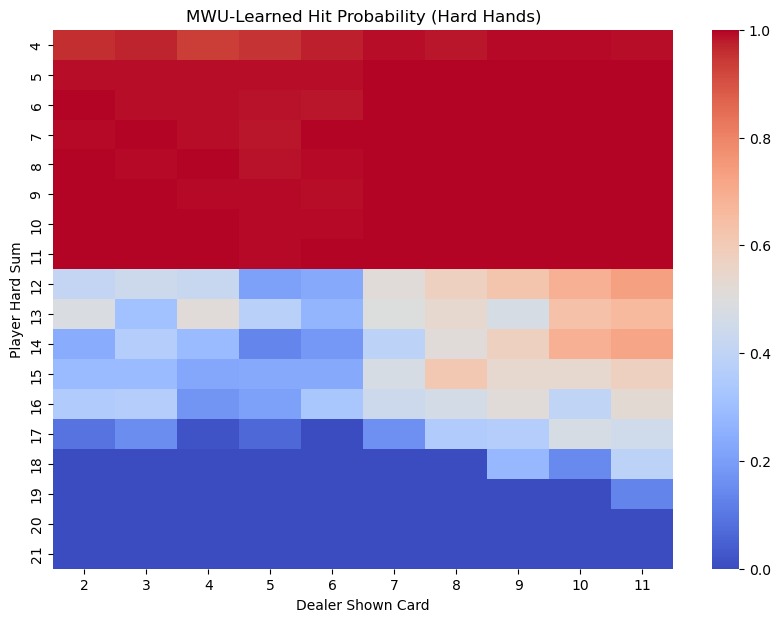

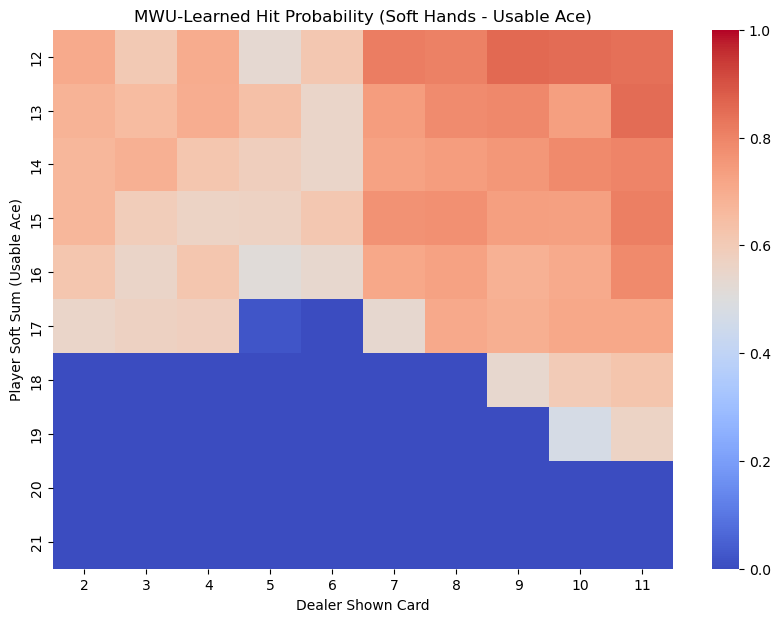

In [ ]:
long_time_player = simulate(10_000_000)

After training for 10 million hands the MWU winrate improves to 42%\
The agent always hits below 12 since there is never a risk to bust and typically hits between 12~16 when the dealer is showing an 8 or higher. While the agent is holding an ace it hits up to 17, excpetions when the dealer shows a 5 or 6. I believe that the agent is prioritizing the dealer busting over trying to beat them, in fact the agent only seems to confidently hit when the dealer is showing a 7 or more. We see less certainty on 18 and 19 when the dealer shows a 9, 10, or 11, generally where the dealer has a higher probability of having a good hand and wouldn't bust as often.

Win rate: 42.62% after 1000000 hands


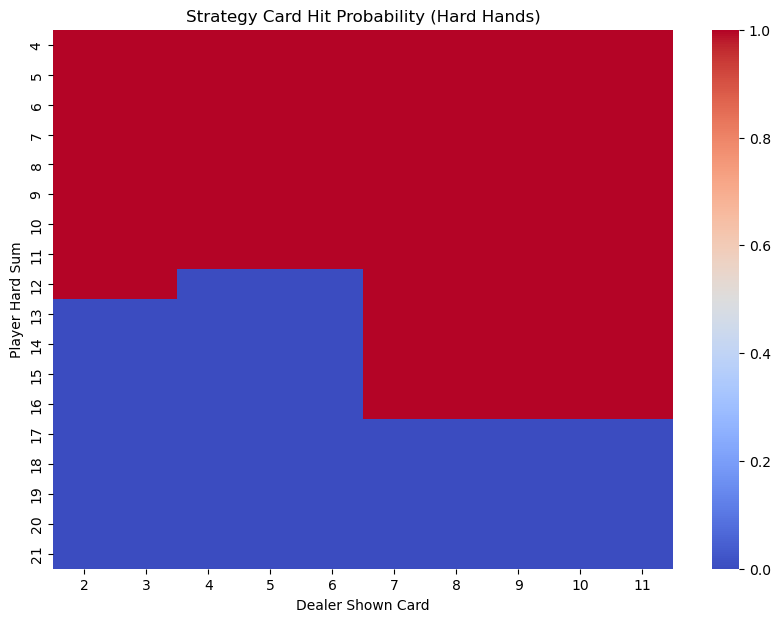

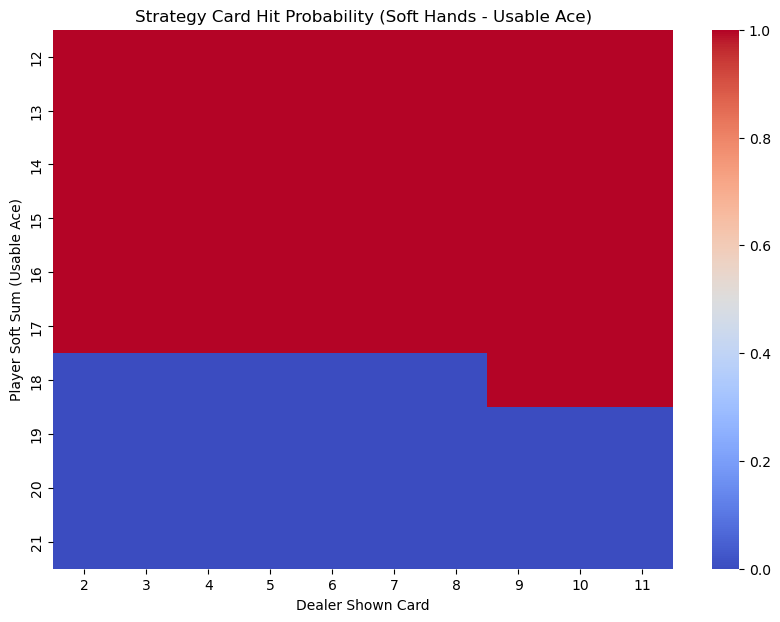

In [34]:
class strategy_card:
    def __init__(self):
        self.weights = defaultdict(lambda: [0.5, 0.5])  # [hit, stand]
        # Hard hands
        for dealer in range(2, 12):  # 11 = Ace
            for total in range(4, 22):
                if (dealer in range(2, 4) and total < 13) or (dealer in range(4, 7) and total < 12) or (dealer in range(7, 12) and total < 17):
                    self.weights[(dealer, total)] = [1.0, 0.0]  # hit
                else:
                    self.weights[(dealer, total)] = [0.0, 1.0]  # stand
        # Soft hands
        for dealer in range(2, 12):
            for hard in range(2, 12):  # hard portion ignoring Ace value
                soft = hard + 10
                if soft > 21:
                    continue

                if dealer in range(2, 9):      # dealer 2–8
                    hit = soft < 18            # hit below soft 18
                else:                           # dealer 9,10,A
                    hit = soft < 19            # hit below soft 19

                self.weights[(dealer, hard, soft)] = [1.0, 0.0] if hit else [0.0, 1.0]

    def policy(self, state):
        return self.weights[state]

    def act(self, state):
        return random.choices(["hit", "stand"], weights=self.policy(state))[0]


def simulate_strategy_card(episodes=100000):
    agent = strategy_card()
    results = []

    for _ in range(episodes):
        env = BlackJack()
        hard, soft = env.player_values()
        dealer_card = env.dealer_shown
        has_ace = 11 in env.player_hand
        state = (dealer_card, hard, soft) if has_ace else (dealer_card, soft)
        done = False

        while not done:
            action = agent.act(state)

            if action == "hit":
                env.player_hand.append(env.draw())
                hard, soft = env.player_values()
                has_ace = 11 in env.player_hand
                if min(hard, soft) > 21:
                    reward = -1
                    done = True
                else:
                    state = (dealer_card, hard, soft) if has_ace else (dealer_card, soft)
                    continue
            else:
                reward = env.result()
                done = True

            results.append(reward)

    win_rate = (sum(1 for r in results if r == 1) / len(results)) * 100
    print(f"Win rate: {win_rate:.2f}% after {episodes} hands")

    # === Visualization ===
    # Separate hard and soft state maps
    data_hard, data_soft = [], []

    for state, (w_hit, w_stand) in agent.weights.items():
        hit_prob = w_hit / (w_hit + w_stand)

        if len(state) == 2:
            dealer, total = state
            data_hard.append({
                "Dealer": dealer,
                "PlayerSum": total,
                "HitProb": hit_prob
            })
        elif len(state) == 3:
            dealer, hard, soft = state
            data_soft.append({
                "Dealer": dealer,
                "PlayerSum": soft,
                "HitProb": hit_prob
            })

    # Helper to plot a dataframe if nonempty
    def plot_state_heatmap(df, title, ylabel):
        if not df:
            return
        df = pd.DataFrame(df)
        pivot = df.pivot_table(index="PlayerSum", columns="Dealer", values="HitProb", aggfunc="first")

        plt.figure(figsize=(10, 7))
        sns.heatmap(pivot, cmap="coolwarm", vmin=0, vmax=1)
        plt.title(title)
        plt.xlabel("Dealer Shown Card")
        plt.ylabel(ylabel)
        plt.show()

    # --- Three plots ---
    plot_state_heatmap(data_hard,
                    "Strategy Card Hit Probability (Hard Hands)",
                    "Player Hard Sum")
    plot_state_heatmap(data_soft,
                    "Strategy Card Hit Probability (Soft Hands - Usable Ace)",
                    "Player Soft Sum (Usable Ace)")

    return agent


card_player = simulate_strategy_card(1_000_000)


This is a similar agent class for a heuristic player. I found blackjack strategy guides and they generally agreed on these acitons in the statespace. We see it performs slightly better than our MWU agent, it doesn't rely on randomness (to decide hit/stand) and plays more aggressively. On hard 12-16 hits with absolute confidence if the dealer is showing 7 or more, and with an ace in hand this model says never to stand on 17. Where MWU often tries to let the dealer bust, this model takes more actions to beat the dealer's potential hand without busting.

Win rate: 42.04% after 1000000 hands


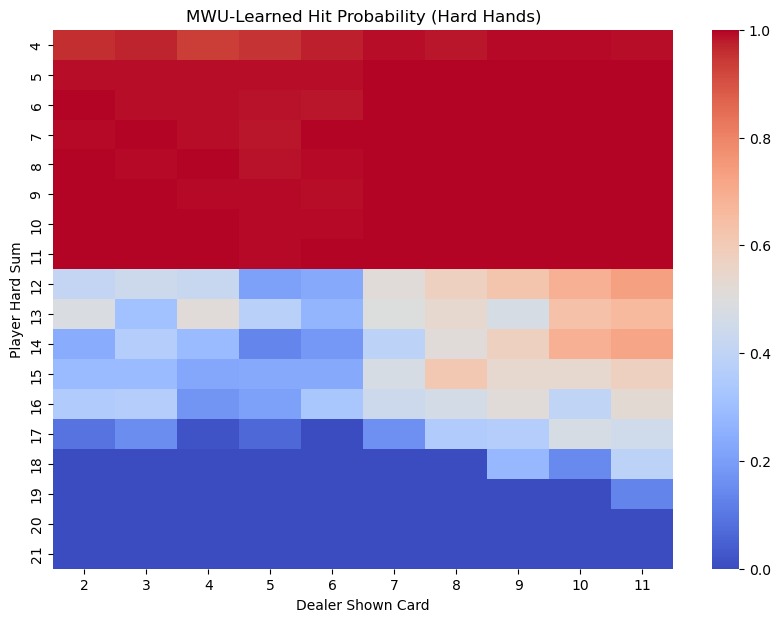

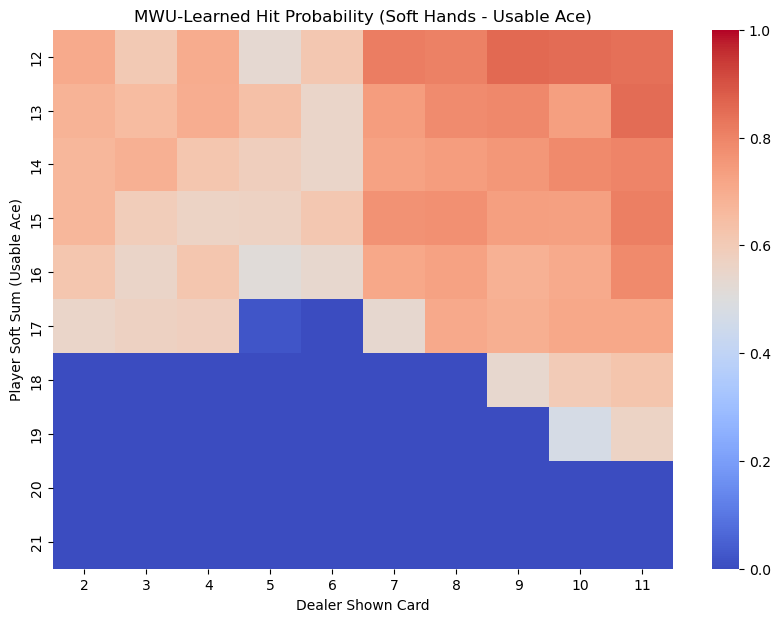

In [33]:
def gamble(agent, episodes=100000):
    results = []

    for _ in range(episodes):
        env = BlackJack()
        hard, soft = env.player_values()
        dealer_card = env.dealer_shown
        has_ace = 11 in env.player_hand
        state = (dealer_card, hard, soft) if has_ace else (dealer_card, soft)
        done = False

        while not done:
            action = agent.act(state)

            if action == "hit":
                env.player_hand.append(env.draw())
                hard, soft = env.player_values()
                has_ace = 11 in env.player_hand
                if min(hard, soft) > 21:
                    reward = -1
                    done = True
                else:
                    state = (dealer_card, hard, soft) if has_ace else (dealer_card, soft)
                    continue
            else:
                reward = env.result()
                done = True
            results.append(reward)

    win_rate = (sum(1 for r in results if r == 1) / len(results)) * 100
    print(f"Win rate: {win_rate:.2f}% after {episodes} hands")

    # === Visualization ===
    # Separate hard and soft state maps
    data_hard, data_soft = [], []

    for state, (w_hit, w_stand) in agent.weights.items():
        hit_prob = w_hit / (w_hit + w_stand)

        if len(state) == 2:
            dealer, total = state
            data_hard.append({
                "Dealer": dealer,
                "PlayerSum": total,
                "HitProb": hit_prob
            })
        elif len(state) == 3:
            dealer, hard, soft = state
            data_soft.append({
                "Dealer": dealer,
                "PlayerSum": soft,
                "HitProb": hit_prob
            })

    # Helper to plot a dataframe if nonempty
    def plot_state_heatmap(df, title, ylabel):
        if not df:
            return
        df = pd.DataFrame(df)
        df_mean = df.groupby(["PlayerSum", "Dealer"], as_index=False)["HitProb"].mean()
        pivot = df_mean.pivot(index="PlayerSum", columns="Dealer", values="HitProb")

        plt.figure(figsize=(10, 7))
        sns.heatmap(pivot, cmap="coolwarm", vmin=0, vmax=1)
        plt.title(title)
        plt.xlabel("Dealer Shown Card")
        plt.ylabel(ylabel)
        plt.show()

    # --- Three plots ---
    plot_state_heatmap(data_hard,
                    "MWU-Learned Hit Probability (Hard Hands)",
                    "Player Hard Sum")
    plot_state_heatmap(data_soft,
                    "MWU-Learned Hit Probability (Soft Hands - Usable Ace)",
                    "Player Soft Sum (Usable Ace)")

gamble(long_time_player, 1_000_000)

For fairness I want to only count the results for the trained agent, with a slight improvement still ~.6% lower than the strategy card while using a more passive strategy allowing more room for the dealer to bust.

Win rate: 42.66% after 1000000 hands


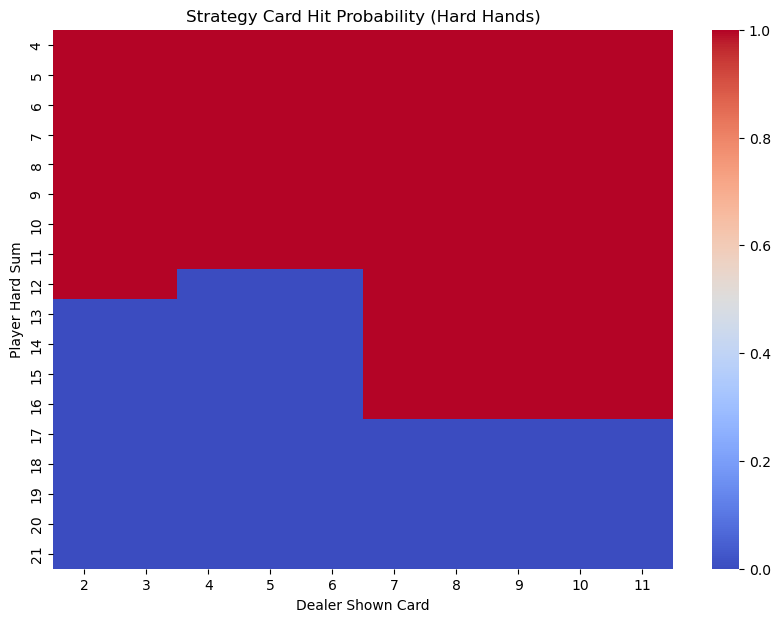

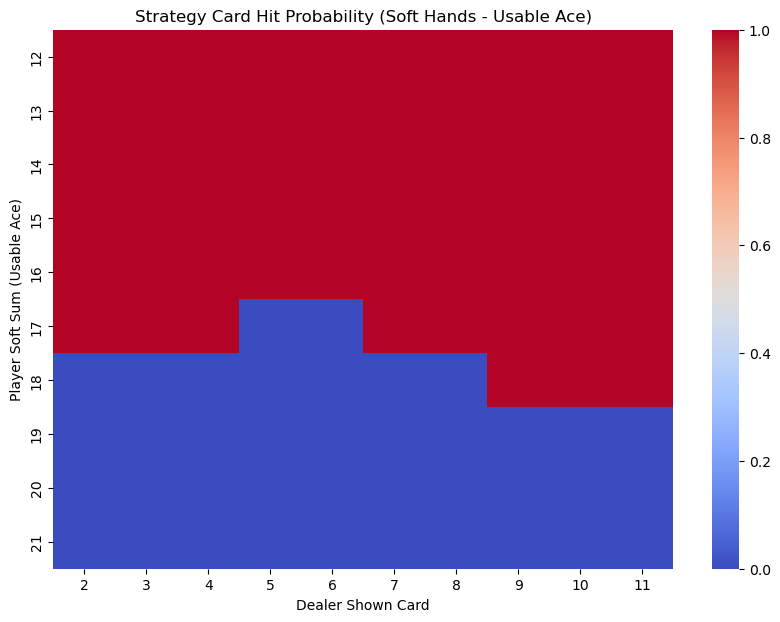

In [32]:
class strategy_card_plus:
    def __init__(self):
        self.weights = defaultdict(lambda: [0.5, 0.5])  # [hit, stand]
        # Hard hands
        for dealer in range(2, 12):  # 11 = Ace
            for total in range(4, 22):
                if (dealer in range(2, 4) and total < 13) or (dealer in range(4, 7) and total < 12) or (dealer in range(7, 12) and total < 17):
                    self.weights[(dealer, total)] = [1.0, 0.0]  # hit
                else:
                    self.weights[(dealer, total)] = [0.0, 1.0]  # stand
        # Soft hands
        for dealer in range(2, 12):
            for hard in range(2, 12):  # hard portion ignoring Ace value
                soft = hard + 10
                if soft > 21:
                    continue

                if dealer in range(2, 5) or dealer in range(7, 9):
                    hit = soft < 18
                elif dealer in range(5, 7):
                    hit = soft < 17
                else:
                    hit = soft < 19

                self.weights[(dealer, hard, soft)] = [1.0, 0.0] if hit else [0.0, 1.0]

    def policy(self, state):
        return self.weights[state]

    def act(self, state):
        return random.choices(["hit", "stand"], weights=self.policy(state))[0]


def simulate_strategy_card_plus(episodes=100000):
    agent = strategy_card_plus()
    results = []

    for _ in range(episodes):
        env = BlackJack()
        hard, soft = env.player_values()
        dealer_card = env.dealer_shown
        has_ace = 11 in env.player_hand
        state = (dealer_card, hard, soft) if has_ace else (dealer_card, soft)
        done = False

        while not done:
            action = agent.act(state)

            if action == "hit":
                env.player_hand.append(env.draw())
                hard, soft = env.player_values()
                has_ace = 11 in env.player_hand
                if min(hard, soft) > 21:
                    reward = -1
                    done = True
                else:
                    state = (dealer_card, hard, soft) if has_ace else (dealer_card, soft)
                    continue
            else:
                reward = env.result()
                done = True

            results.append(reward)

    win_rate = (sum(1 for r in results if r == 1) / len(results)) * 100
    print(f"Win rate: {win_rate:.2f}% after {episodes} hands")

    # === Visualization ===
    # Separate hard and soft state maps
    data_hard, data_soft = [], []

    for state, (w_hit, w_stand) in agent.weights.items():
        hit_prob = w_hit / (w_hit + w_stand)

        if len(state) == 2:
            dealer, total = state
            data_hard.append({
                "Dealer": dealer,
                "PlayerSum": total,
                "HitProb": hit_prob
            })
        elif len(state) == 3:
            dealer, hard, soft = state
            data_soft.append({
                "Dealer": dealer,
                "PlayerSum": soft,
                "HitProb": hit_prob
            })

    # Helper to plot a dataframe if nonempty
    def plot_state_heatmap(df, title, ylabel):
        if not df:
            return
        df = pd.DataFrame(df)
        pivot = df.pivot_table(index="PlayerSum", columns="Dealer", values="HitProb", aggfunc="first")

        plt.figure(figsize=(10, 7))
        sns.heatmap(pivot, cmap="coolwarm", vmin=0, vmax=1)
        plt.title(title)
        plt.xlabel("Dealer Shown Card")
        plt.ylabel(ylabel)
        plt.show()

    # --- Three plots ---
    plot_state_heatmap(data_hard,
                    "Strategy Card Hit Probability (Hard Hands)",
                    "Player Hard Sum")
    plot_state_heatmap(data_soft,
                    "Strategy Card Hit Probability (Soft Hands - Usable Ace)",
                    "Player Soft Sum (Usable Ace)")

    return agent


card_player = simulate_strategy_card_plus(1_000_000)


When we change sum=17 on dealer's 5,6 to stand like MWU decided, we actually see a small (unsteady) increase to the strategy's score.